# Deep Learning Project — 3-Class TensorFlow CNN

Classes:

- `INVALID`
- `NORMAL`
- `PNEUMONIA`

The goal is to avoid forcing every random image into NORMAL or PNEUMONIA.

### Input folders

```text
images/
├── INVALID/
├── NORMAL/
└── PNEUMONIA/
```

For the classroom demo:

- Put one original NORMAL chest X-ray in `images/NORMAL/`
- Put one original PNEUMONIA chest X-ray in `images/PNEUMONIA/`
- Put several genuinely different unrelated images in `images/INVALID/`

Examples for INVALID: car, cat, building, food, screenshot, landscape, person, document, etc.

> Important: augmentation cannot create real diversity from one source image. This is a classroom demonstration, not a clinically valid model.


In [1]:
from pathlib import Path
import shutil
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices("GPU"))


I0000 00:00:1788545005.570061   25701 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788545005.641754   25701 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788545007.264607   25701 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
SEED = 123
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 20

AUGMENTED_NORMAL = 200
AUGMENTED_PNEUMONIA = 200
AUGMENTED_PER_INVALID_SOURCE = 20

SOURCE_DIR = Path("images")
GENERATED_DIR = Path("generated_images")

CLASS_NAMES = [
    "INVALID",
    "NORMAL",
    "PNEUMONIA"
]

VALID_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

tf.keras.utils.set_random_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)


In [3]:
def image_files(folder):
    return [
        p for p in sorted(folder.iterdir())
        if p.is_file()
        and p.suffix.lower() in VALID_EXTENSIONS
    ]

normal_sources = image_files(
    SOURCE_DIR / "NORMAL"
)

pneumonia_sources = image_files(
    SOURCE_DIR / "PNEUMONIA"
)

invalid_sources = image_files(
    SOURCE_DIR / "INVALID"
)

if not normal_sources:
    raise FileNotFoundError(
        "Add at least one NORMAL image to images/NORMAL/"
    )

if not pneumonia_sources:
    raise FileNotFoundError(
        "Add at least one PNEUMONIA image to images/PNEUMONIA/"
    )

if not invalid_sources:
    raise FileNotFoundError(
        "Add unrelated images to images/INVALID/"
    )

print("NORMAL source images:", len(normal_sources))
print("PNEUMONIA source images:", len(pneumonia_sources))
print("INVALID source images:", len(invalid_sources))


NORMAL source images: 1
PNEUMONIA source images: 1
INVALID source images: 10


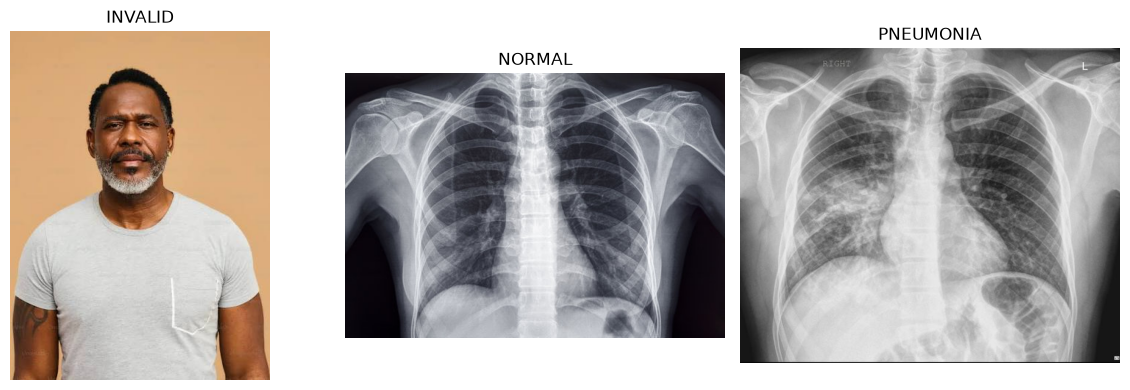

In [4]:
normal_image = Image.open(
    normal_sources[0]
).convert("RGB")

pneumonia_image = Image.open(
    pneumonia_sources[0]
).convert("RGB")

invalid_image = Image.open(
    invalid_sources[0]
).convert("RGB")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(invalid_image)
plt.title("INVALID")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(normal_image)
plt.title("NORMAL")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pneumonia_image)
plt.title("PNEUMONIA")
plt.axis("off")

plt.tight_layout()
plt.show()


In [5]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.04, 0.04),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.10),
])

I0000 00:00:1788545008.729343   25701 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4132 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


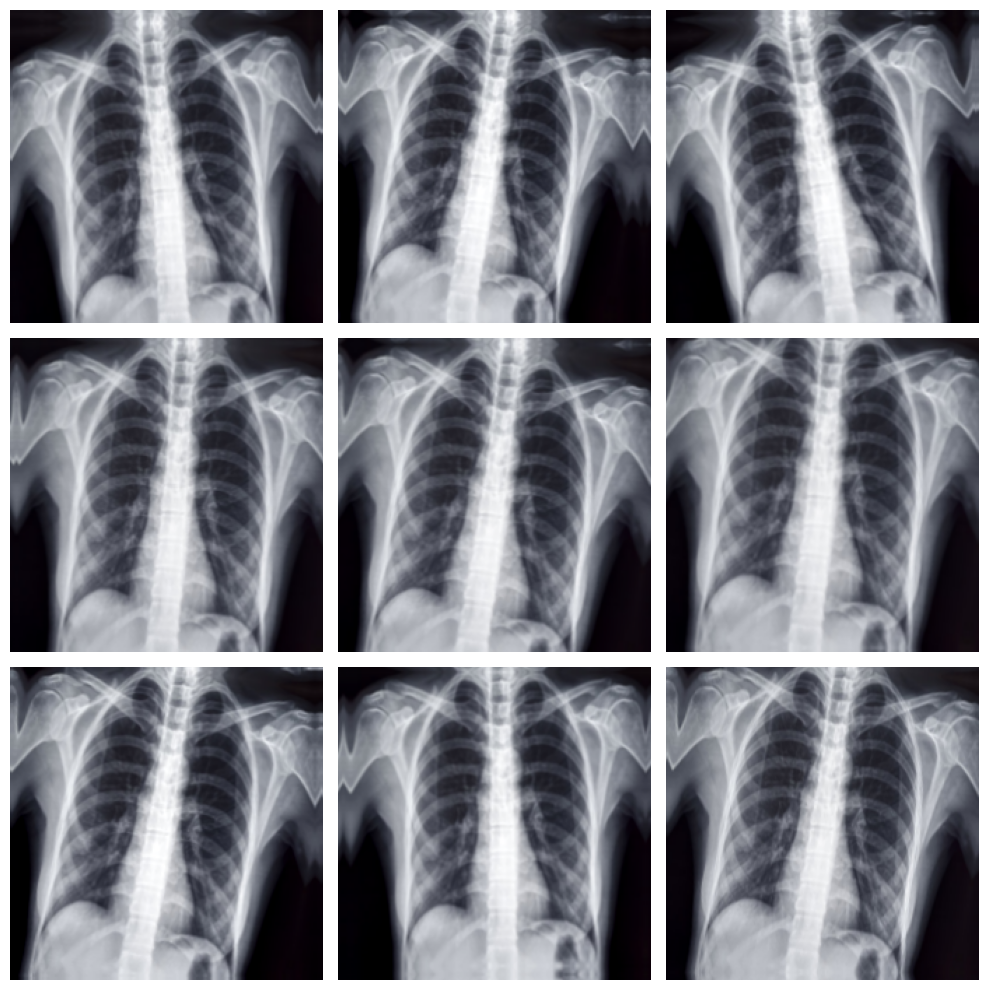

In [6]:
preview = normal_image.resize(
    IMAGE_SIZE
)

x = tf.expand_dims(
    tf.convert_to_tensor(
        np.array(preview),
        dtype=tf.float32
    ),
    axis=0
)

plt.figure(figsize=(10, 10))

for i in range(9):
    y = augmentation(
        x,
        training=True
    )[0]

    y = tf.clip_by_value(
        y,
        0,
        255
    )

    plt.subplot(
        3,
        3,
        i + 1
    )

    plt.imshow(
        tf.cast(
            y,
            tf.uint8
        )
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
if GENERATED_DIR.exists():
    shutil.rmtree(
        GENERATED_DIR
    )

for class_name in CLASS_NAMES:
    (
        GENERATED_DIR /
        class_name
    ).mkdir(
        parents=True,
        exist_ok=True
    )

def save_augmented(
    source_path,
    destination,
    prefix,
    count
):
    image = Image.open(
        source_path
    ).convert("RGB")

    image = image.resize(
        IMAGE_SIZE
    )

    image_array = np.array(
        image,
        dtype=np.float32
    )

    image_batch = tf.expand_dims(
        image_array,
        axis=0
    )

    tf.keras.utils.save_img(
        destination /
        f"{prefix}_original.jpg",
        image_array
    )

    for i in range(count):
        augmented = augmentation(
            image_batch,
            training=True
        )[0]

        augmented = tf.clip_by_value(
            augmented,
            0,
            255
        )

        tf.keras.utils.save_img(
            destination /
            f"{prefix}_aug_{i+1:03d}.jpg",
            augmented
        )


In [8]:
# NORMAL
save_augmented(
    normal_sources[0],
    GENERATED_DIR / "NORMAL",
    "normal",
    AUGMENTED_NORMAL
)

# PNEUMONIA
save_augmented(
    pneumonia_sources[0],
    GENERATED_DIR / "PNEUMONIA",
    "pneumonia",
    AUGMENTED_PNEUMONIA
)

# INVALID
# Use many genuinely different invalid originals.
for source_index, source_path in enumerate(
    invalid_sources,
    start=1
):
    save_augmented(
        source_path,
        GENERATED_DIR / "INVALID",
        f"invalid_{source_index:03d}",
        AUGMENTED_PER_INVALID_SOURCE
    )

for class_name in CLASS_NAMES:
    count = len(
        list(
            (
                GENERATED_DIR /
                class_name
            ).glob("*.jpg")
        )
    )

    print(
        class_name,
        "generated:",
        count
    )


INVALID generated: 210
NORMAL generated: 201
PNEUMONIA generated: 201


In [9]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    GENERATED_DIR,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    GENERATED_DIR,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_dataset.class_names

print("Class names:", class_names)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    tf.data.AUTOTUNE
)

Found 612 files belonging to 3 classes.
Using 490 files for training.
Found 612 files belonging to 3 classes.
Using 122 files for validation.
Class names: ['INVALID', 'NORMAL', 'PNEUMONIA']


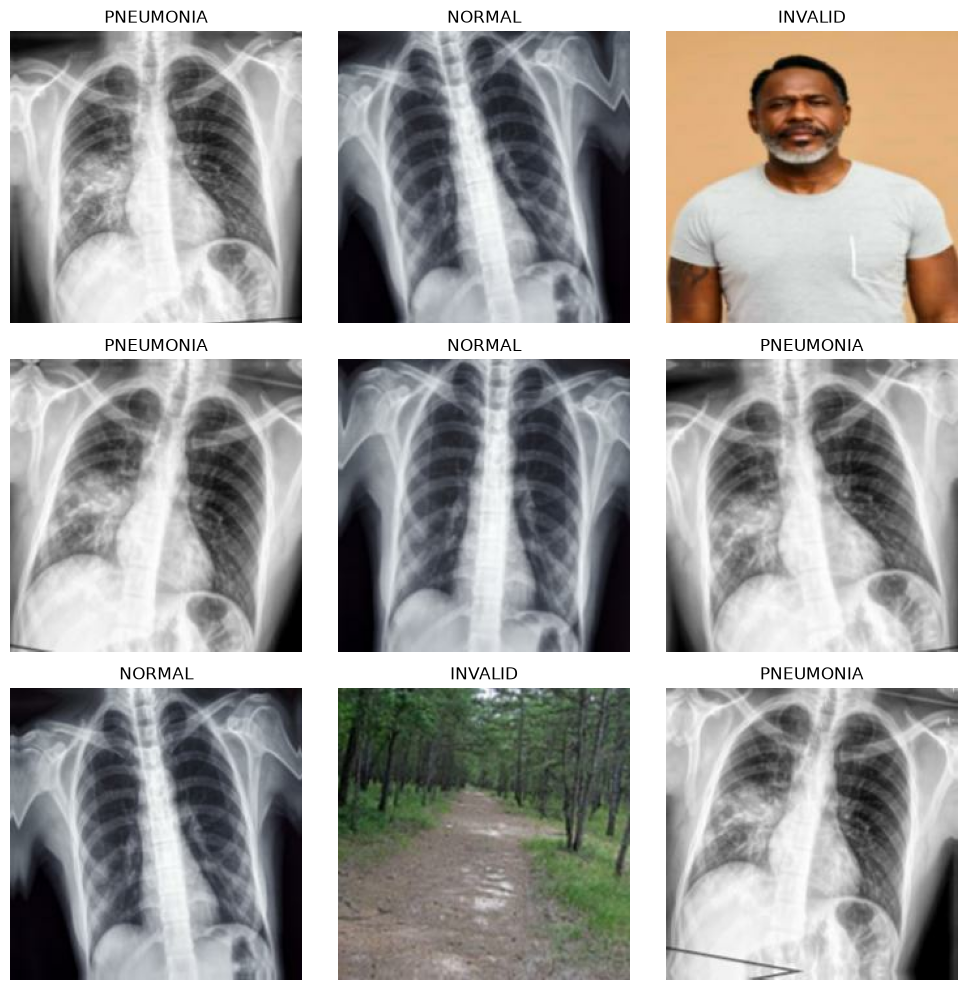

In [10]:
images_batch, labels_batch = next(
    iter(train_dataset)
)

plt.figure(figsize=(10, 10))

for i in range(
    min(9, len(images_batch))
):
    plt.subplot(
        3,
        3,
        i + 1
    )

    plt.imshow(
        tf.cast(
            images_batch[i],
            tf.uint8
        )
    )

    plt.title(
        class_names[
            int(labels_batch[i])
        ]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),

    augmentation,

    tf.keras.layers.Rescaling(1.0 / 255.0),

    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(3, activation="softmax")
])

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        "accuracy"
    ]
)


In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]


In [14]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/20


/home/faiz-sheikh/Downloads/DL_simple_tensorflow/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788545034.741824   25779 cuda_dnn.cc:461] Loaded cuDNN version 92501


31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.3939 - loss: 1.0797 - val_accuracy: 0.3770 - val_loss: 1.0442 - learning_rate: 0.0010
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6592 - loss: 0.7771 - val_accuracy: 0.9590 - val_loss: 0.4794 - learning_rate: 0.0010
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8633 - loss: 0.3628 - val_accuracy: 0.9508 - val_loss: 0.1831 - learning_rate: 0.0010
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9633 - loss: 0.1459 - val_accuracy: 0.9918 - val_loss: 0.1670 - learning_rate: 0.0010
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9796 - loss: 0.0845 - val_accuracy: 1.0000 - val_loss: 0.0200 - learning_rate: 0.0010
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 1.0000 - loss: 0.0175 - val_accuracy: 1.0000 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9980 - loss: 0.0199 - val_accuracy: 0.74

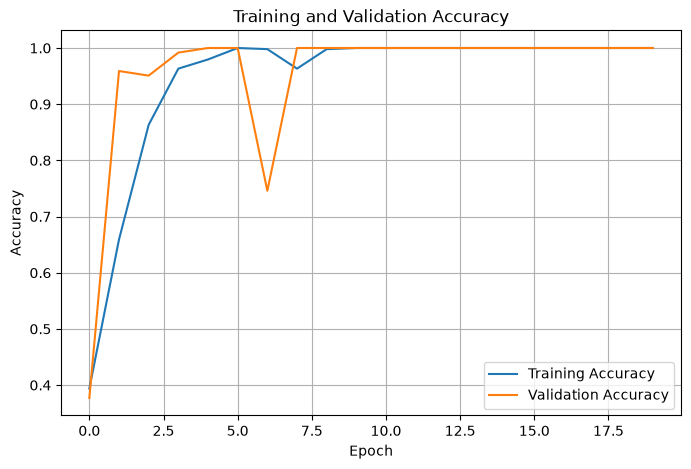

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)
plt.show()


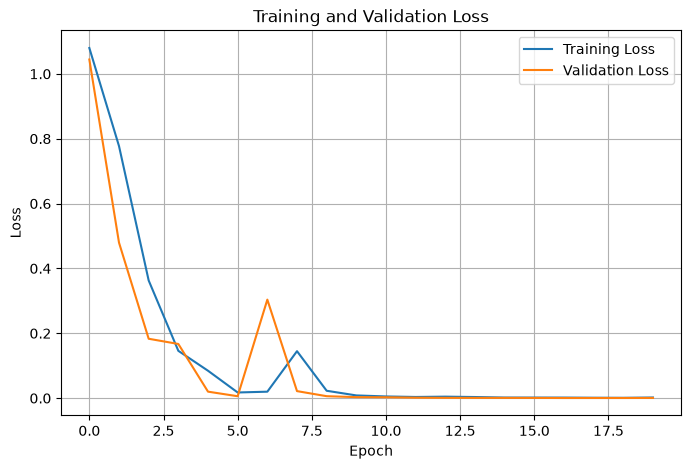

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid(True)
plt.show()


In [17]:
validation_loss, validation_accuracy = model.evaluate(
    validation_dataset,
    verbose=1
)

print(
    "Validation loss:",
    validation_loss
)

print(
    "Validation accuracy:",
    validation_accuracy
)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 4.4693e-04
Validation loss: 0.00044693078962154686
Validation accuracy: 1.0


In [18]:
model.save(
    "model.keras"
)

print(
    "Model saved successfully as model.keras"
)


Model saved successfully as model.keras


In [19]:
sample_images, sample_labels = next(
    iter(validation_dataset)
)

probabilities = model.predict(
    sample_images[:1],
    verbose=0
)[0]

predicted_index = int(
    np.argmax(probabilities)
)

actual_index = int(
    sample_labels[0]
)

print(
    "Actual:",
    class_names[actual_index]
)

print(
    "Predicted:",
    class_names[predicted_index]
)

print(
    "Probabilities:",
    {
        class_names[i]:
        float(probabilities[i])
        for i in range(3)
    }
)


Actual: INVALID
Predicted: INVALID
Probabilities: {'INVALID': 1.0, 'NORMAL': 1.6471047997260462e-16, 'PNEUMONIA': 3.320749325446387e-17}


In [20]:
validation_count = 0

for images, labels in validation_dataset:
    validation_count += len(labels)

print("Validation images:", validation_count)

Validation images: 122


In [21]:
for images, labels in validation_dataset:
    probabilities = model.predict(images, verbose=0)

    predicted = np.argmax(
        probabilities,
        axis=1
    )

    for actual, pred, probs in zip(
        labels.numpy(),
        predicted,
        probabilities
    ):
        print(
            "Actual:",
            class_names[int(actual)],
            "| Predicted:",
            class_names[int(pred)],
            "| Probabilities:",
            np.round(probs, 3)
        )

Actual: PNEUMONIA | Predicted: PNEUMONIA | Probabilities: [0. 0. 1.]
Actual: INVALID | Predicted: INVALID | Probabilities: [1. 0. 0.]
Actual: PNEUMONIA | Predicted: PNEUMONIA | Probabilities: [0. 0. 1.]
Actual: INVALID | Predicted: INVALID | Probabilities: [1. 0. 0.]
Actual: NORMAL | Predicted: NORMAL | Probabilities: [0.001 0.999 0.   ]
Actual: NORMAL | Predicted: NORMAL | Probabilities: [0.001 0.999 0.   ]
Actual: PNEUMONIA | Predicted: PNEUMONIA | Probabilities: [0. 0. 1.]
Actual: PNEUMONIA | Predicted: PNEUMONIA | Probabilities: [0. 0. 1.]
Actual: INVALID | Predicted: INVALID | Probabilities: [1. 0. 0.]
Actual: PNEUMONIA | Predicted: PNEUMONIA | Probabilities: [0. 0. 1.]
Actual: INVALID | Predicted: INVALID | Probabilities: [1. 0. 0.]
Actual: NORMAL | Predicted: NORMAL | Probabilities: [0.001 0.999 0.   ]
Actual: INVALID | Predicted: INVALID | Probabilities: [1. 0. 0.]
Actual: NORMAL | Predicted: NORMAL | Probabilities: [0.001 0.999 0.   ]
Actual: PNEUMONIA | Predicted: PNEUMONIA |

In [22]:
from pathlib import Path

for class_name in ["INVALID", "NORMAL", "PNEUMONIA"]:
    folder = Path("generated_images") / class_name

    files = [
        p for p in folder.iterdir()
        if p.is_file()
    ]

    print(
        class_name,
        ":",
        len(files)
    )

INVALID : 210
NORMAL : 201
PNEUMONIA : 201


In [23]:
print(
    "Training batches:",
    tf.data.experimental.cardinality(
        train_dataset
    ).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(
        validation_dataset
    ).numpy()
)

Training batches: 31
Validation batches: 8


In [24]:
train_count = 0

for images, labels in train_dataset:
    train_count += len(labels)

validation_count = 0

for images, labels in validation_dataset:
    validation_count += len(labels)

print("Training images:", train_count)
print("Validation images:", validation_count)

Training images: 490
Validation images: 122


In [27]:
from pathlib import Path
from PIL import Image
import numpy as np

TEST_DIR = Path("test_images")

for image_path in TEST_DIR.iterdir():
    if not image_path.is_file():
        continue

    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMAGE_SIZE)

    x = np.array(image, dtype=np.float32)
    x = np.expand_dims(x, axis=0)

    probabilities = model.predict(
        x,
        verbose=0
    )[0]

    predicted_index = int(
        np.argmax(probabilities)
    )

    print(
        image_path.name,
        "->",
        class_names[predicted_index],
        np.round(probabilities, 4)
    )

5images.jpeg -> INVALID [1. 0. 0.]
76052f7902246ff862f52f5d3cd9cd_big_gallery.jpg -> NORMAL [0.0086 0.9693 0.0221]
images.jpeg -> INVALID [1. 0. 0.]
landscape-photography-tips-yosemite-valley-feature.jpg -> INVALID [1. 0. 0.]
1images.jpeg -> INVALID [1. 0. 0.]
pnawee.jpg -> PNEUMONIA [0.     0.0036 0.9964]
images.jpg -> PNEUMONIA [0.000e+00 1.000e-04 9.999e-01]
im5ages.jpeg -> INVALID [1. 0. 0.]
